# Explaining CNNs with Integrated Gradients and Grad-CAM

This notebook trains a ResNet-18 on the Cats vs Dogs dataset and applies Integrated Gradients and Grad-CAM to explain predictions.

In [4]:
!pip install datasets captum -q

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution

## Load Dataset

In [3]:
dataset = load_dataset('pantelism/cats-vs-dogs')

Generating test split: 100%|██████████| 1000/1000 [00:00<00:00, 33359.08 examples/s]


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [6]:
class CatsDogsDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        return self.transform(sample['image']), sample['label']

In [7]:
train_ds = CatsDogsDataset(dataset['train'], train_transform)
val_ds = CatsDogsDataset(dataset['validation'], test_transform)
test_ds = CatsDogsDataset(dataset['test'], test_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

## Train ResNet-18

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/anderson/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 60.4MB/s]


In [9]:
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f'Epoch {epoch+1}: {running_loss/len(train_loader):.4f}')

Epoch 1: 0.1486
Epoch 2: 0.0460
Epoch 3: 0.0179


## Test Accuracy

In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print('Accuracy:', correct/total)

Accuracy: 0.97


## Find 3 Correct and 1 Incorrect Example

In [22]:
correct_examples = []
wrong_example = None

for image, label in test_ds:
    x = image.unsqueeze(0).to(device)
    pred = model(x).argmax(1).item()

    if pred == label and len(correct_examples) < 3:
        correct_examples.append((image, label))
    elif pred != label and wrong_example is None:
        wrong_example = (image, label)

    if len(correct_examples) == 3 and wrong_example is not None:
        break

## Integrated Gradients

In [12]:
ig = IntegratedGradients(model)

In [13]:
def show_integrated_gradients(image):
    x = image.unsqueeze(0).to(device)
    pred = model(x).argmax(1).item()
    attr = ig.attribute(x, baselines=torch.zeros_like(x), target=pred)
    attr = np.mean(np.abs(attr.squeeze().detach().cpu().numpy()), axis=0)
    img = image.permute(1,2,0).numpy()
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img); plt.imshow(attr, cmap='jet', alpha=0.5); plt.axis('off')
    plt.show()

Integrated Gradients is a feature attribution method that explains which input pixels contributed most to a model's prediction. Instead of computing gradients only at the input image, it computes gradients along a path from a baseline image to the actual image and accumulates them. In this notebook, an all-black image is used as the baseline because it represents the absence of visual information.

The resulting attribution map highlights pixels that contributed positively to the predicted class. Unlike ordinary gradients, Integrated Gradients is less affected by gradient saturation and satisfies a completeness property, meaning the attributions sum to the difference between the model's output for the input and the baseline.

One limitation of Integrated Gradients is that the quality of the explanation can depend on the chosen baseline image. Different baselines may produce different attribution maps.

## Grad-CAM

In [14]:
gradcam = LayerGradCam(model, model.layer4[-1])

In [16]:
def show_gradcam(image):
    x = image.unsqueeze(0).to(device)
    pred = model(x).argmax(1).item()
    cam = gradcam.attribute(x, target=pred)
    cam = LayerAttribution.interpolate(cam, x.shape[2:])
    cam = cam.squeeze().detach().cpu().numpy()
    img = image.permute(1,2,0).numpy()
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img); plt.imshow(cam, cmap='jet', alpha=0.5); plt.axis('off')
    plt.show()

Grad-CAM (Gradient-weighted Class Activation Mapping) explains CNN predictions by identifying image regions that were most influential for a specific class prediction. It uses gradients flowing into a convolutional layer to determine which feature maps are most important and combines them into a coarse localization heatmap.

For this experiment, the final convolutional layer of ResNet-18 was selected as the target layer. This layer captures high-level semantic information while still preserving spatial structure, making it suitable for localization.

The resulting heatmap highlights regions that most strongly contributed to the prediction rather than individual pixels.

One limitation of Grad-CAM is its relatively low spatial resolution. While it can identify important regions, it cannot provide detailed pixel-level explanations.

## 3 Correct Examples

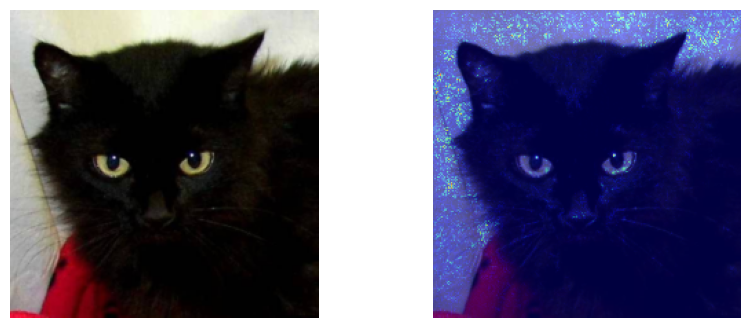

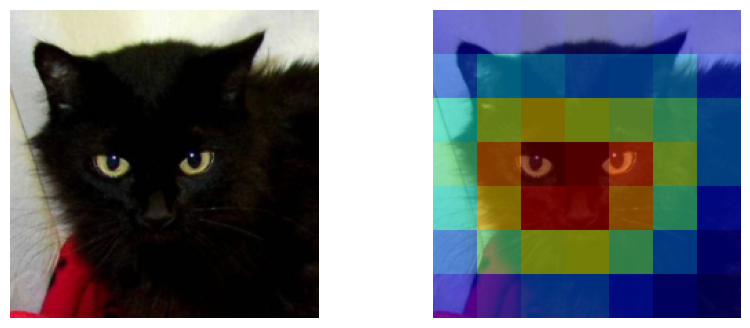

In [26]:
show_integrated_gradients(correct_examples[0][0])
show_gradcam(correct_examples[0][0])

Integrated Gradients Caption: Map highlights the fine-grained contours of the cat's eyes, ears, and nose bridge, while showing a high concentration of scattered background noise that indicates reliance on surrounding contrast boundaries.

Grad-CAM Caption: Map focuses primarily on the central facial block encompassing the cat's eyes and snout, indicating that the network relied heavily on high-level semantic features localized to the core face rather than peripheral elements.

Comparison & Alignment: The two methods agree that the central facial block and eyes are the definitive regions of importance, but they disagree on boundary handling; Integrated Gradients relies on the sharp edge-contrast between the dark fur and the bright background wall, while Grad-CAM remains rigidly confined to the central facial pixels.

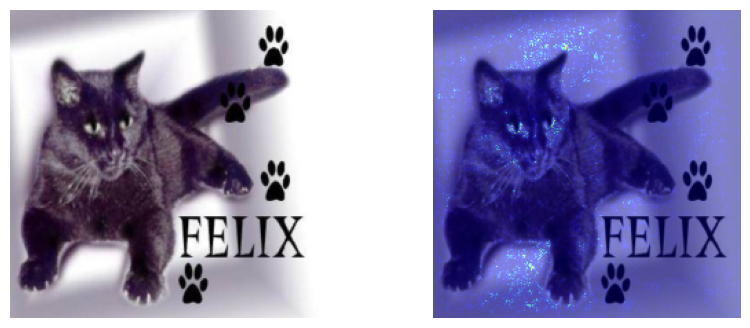

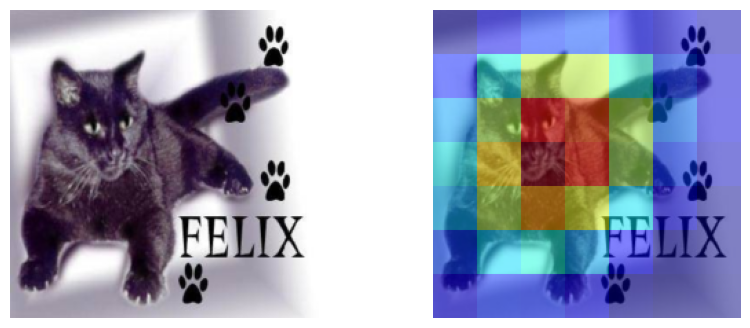

In [27]:
show_integrated_gradients(correct_examples[1][0])
show_gradcam(correct_examples[1][0])

Integrated Gradients Caption: Map shows pixel-level focus concentrated on the high-contrast textures of the cat’s eyes, whiskers, and paws, alongside scattered noise across the fur coat.

Grad-CAM Caption: Map indicates the model focused broadly on the high-level semantic features of the cat’s central torso and lower face, completely ignoring the background text and graphics.

Comparison & Alignment: The two methods agree that the center mass of the cat is the primary focus while ignoring the background text, but they disagree on granularity; Integrated Gradients tracks fine edge details like whiskers, whereas Grad-CAM pools the entire head into a single, coarse region.

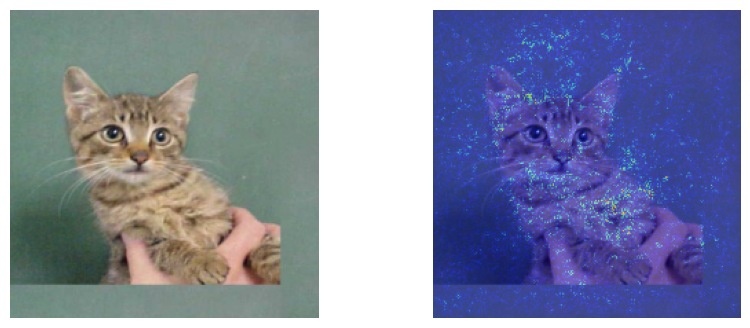

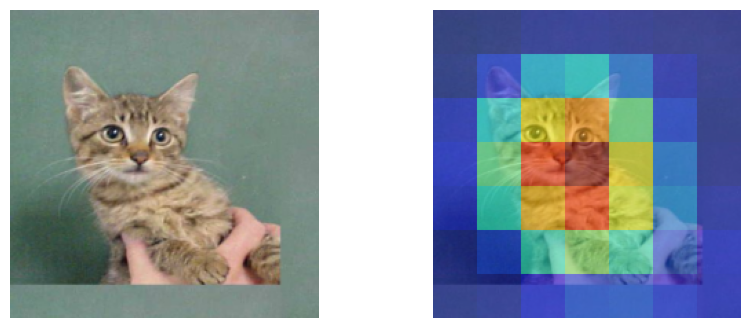

In [28]:
show_integrated_gradients(correct_examples[2][0])
show_gradcam(correct_examples[2][0])

Integrated Gradients Caption: Map captures precise edge-contrast boundaries along the cat’s striped fur, ears, and hand contours, with a faint halo of attribution leaking into the solid background.

Grad-CAM Caption: Map reveals intense regional attention on the cat's face and jaw, with moderate semantic activations extending down to the chest and the grasping human hand.

Comparison & Alignment: The two methods agree that the cat's head is a critical region, but they disagree on background containment; Integrated Gradients suffers from noisy, scattered pixel activations in the empty green space, which Grad-CAM cleanly suppresses.

## Wrong Example

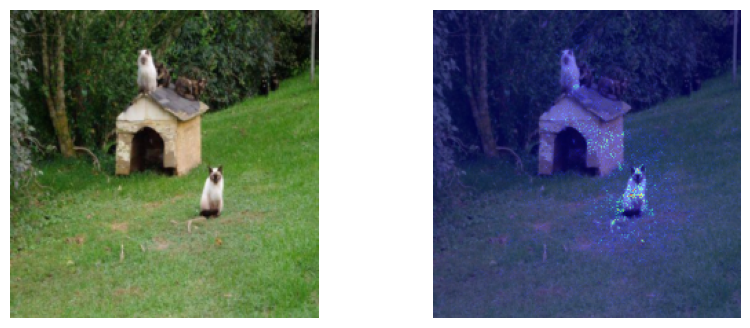

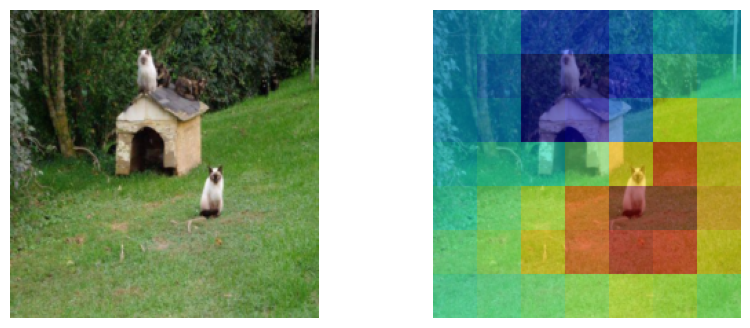

In [29]:
show_integrated_gradients(wrong_example[0])
show_gradcam(wrong_example[0])

Integrated Gradients Caption: Map isolates the specific high-contrast facial features and sharp body contours of the foreground cat, while placing trace attribution on the cat atop the house.

Grad-CAM Caption: Map demonstrates strong localization on the foreground cat and its immediate surrounding lawn patch, entirely suppressing the distant animal and the background structure.

Comparison & Alignment: Both methods agree on ignoring the doghouse and isolating the lower foreground cat, but they disagree on spatial boundaries; Grad-CAM expands its focus into the surrounding green grass pixels, while Integrated Gradients strictly binds itself to the animal's sharp bodily contours.

Model Learning Insight (The Mismatch): This misclassification reveals that the model did not learn the high-level conceptual geometry of a "doghouse environment," nor did it use the background structure for context; instead, it mistakenly over-indexed on the foreground cat's local fur textures and grass context, causing it to misclassify the scene based on a single isolated subject.